# The Mann et al. (2023) heliospheric density model

A guided implementation of the radial density profile from
Mann, Warmuth, Vocks & Rouillard, *A&A* **679**, A64 (2023).

The paper presents a model of the electron density $N_e(r)$, proton speed
$v_p(r)$, magnetic field, and Alfvén speed from the coronal base out to
$\sim 250\,R_\odot$. This notebook focuses on $N_e(r)$ and $v_p(r)$, which
is what you need to convert a solar radio burst's frequency drift into a
heliocentric distance trajectory.

**What you will get out of this notebook:**

1. An understanding of how the model's two free parameters $T$ and $C_e$ fix everything else.
2. A working solver for Parker's isothermal wind equation.
3. A function that maps $(f, t)$ points from a dynamic spectrum to $(r, t)$.
4. A set of checks that tell you whether your implementation is actually correct (as opposed to merely *looking* correct).

## 1. The physics in one page

Two equations do all the work.

**Parker's isothermal wind equation** (Eq. 9 of the paper). The solar wind is
described as a steady, spherically symmetric, isothermal flow. Conservation
of momentum then gives:

$$v'^{\,2} - \ln v'^{\,2} \;=\; 4 \ln r' + \frac{4}{r'} - 3,$$

where $v' = v/v_c$ and $r' = r/r_c$. The **critical (sonic) speed** $v_c$ and
**critical radius** $r_c$ are:

$$v_c = \sqrt{\frac{k_B T}{\tilde\mu\, m_p}}, \qquad r_c = \frac{G M_\odot}{2 v_c^{\,2}}.$$

So picking the coronal temperature $T$ fixes both $v_c$ and $r_c$ automatically.
Parker's equation then tells you $v(r)$ at every radius — no additional input needed.

**Continuity** (Eq. 10). In a steady spherical flow, the number of particles
crossing every shell per second is the same:

$$r^{2}\, N_e(r)\, v(r) \;=\; \text{constant} \;\equiv\; C_e.$$

$C_e$ is the second free parameter. It is the conserved particle flux constant
(divided by $4\pi$). Once you have $v(r)$ from Parker's equation and you fix
$C_e$ from observations, $N_e(r) = C_e / [r^2 v(r)]$ is determined everywhere.

That is the whole model: two free parameters, $T$ and $C_e$, and two equations.

## 2. Where does $N_{i,c}$ come from?

Equation 11 of the paper writes the *near-Sun* limit for particle species $i$ as

$$N_i(r) \;=\; N_{i,\odot}\, \exp\!\left(\frac{2 r_c}{R_\odot}\left[\frac{R_\odot}{r} - 1\right]\right), \qquad N_{i,\odot} \;=\; N_{i,c}\, \exp\!\left(\frac{2 r_c}{R_\odot} - \frac{3}{2}\right),$$

and it is tempting to treat $N_{i,c}$ as a third free parameter. It is not.
Continuity holds for each species $i$ separately (electrons, protons,
$\alpha$-particles), and evaluating it right *at* the critical point — where by
definition $r = r_c$ and $v = v_c$ — gives:

$$C_i \;=\; r_c^{\,2}\, N_{i,c}\, v_c \quad\Longrightarrow\quad N_{i,c} \;=\; \frac{C_i}{r_c^{\,2}\, v_c}.$$

So $N_{i,c}$ is whatever density makes the flux equal to $C_i$ at the sonic point.
Once $T$ and $C_i$ are chosen, $N_{i,c}$ is forced. You never set it by hand.

**Switching between species is trivial.** $v_c$ and $r_c$ are properties of the
bulk fluid (set by $T$ and $\tilde\mu$), so they are the same for every species.
The species enters only through $C_i$. With $\nu = N_\text{He}/N_p \approx 0.058$
(Mann et al., Sect. 2), charge neutrality gives

$$N_e \;=\; (1+2\nu)\, N_p \;\approx\; 1.12\, N_p \quad\Longrightarrow\quad C_p \;\approx\; 0.893\, C_e,$$

and the corresponding critical densities are related by the same factors:
$N_{p,c} = N_{e,c}/1.12$ and $N_{\text{He},c} = \nu\, N_{p,c}$.

**The rest of this notebook works in electrons** ($i = e$), because radio emission
is at the local plasma frequency $f_p \propto \sqrt{N_e}$, so for radio-burst
applications $N_e$ is the natural variable. Mann et al.'s best-fit point M is
$T = 1.18\,\text{MK}$ and $C_e = 9.127 \times 10^{34}\,\text{s}^{-1}$, which we adopt
as defaults. If you ever need $N_p$ instead, multiply $N_e$ by $1/(1+2\nu) \approx 0.893$.

## 3. Setting up

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# Physical constants (CGS)
R_SUN  = 6.957e10        # cm
M_SUN  = 1.989e33        # g
G_GRAV = 6.6743e-8       # cm^3 g^-1 s^-2
K_B    = 1.380649e-16    # erg / K
M_P    = 1.67262e-24     # g

## 4. Critical-point quantities

Specialise the general formula to electrons ($i = e$): given $T$ and $C_e$,
compute $v_c$, $r_c$, $N_{e,c}$ directly. The protons follow by the conversion
factors above if you ever need them.

In [2]:
T_MK     = 1.18                # coronal temperature in MK (point M)
C_e      = 9.127e34            # particle flux constant in s^-1 (point M)
mu_tilde = 0.57                # mean molecular weight (Mann+23 Sect. 2)

T_K = T_MK * 1e6
v_c = np.sqrt(K_B * T_K / (mu_tilde * M_P))
r_c = G_GRAV * M_SUN / (2.0 * v_c**2)
N_ec = C_e / (r_c**2 * v_c)

print(f'v_c       = {v_c/1e5:7.2f} km/s')
print(f'r_c       = {r_c/1e8:7.1f} Mm   = {r_c/R_SUN:.3f} R_sun')
print(f'2 r_c/R_sun = {2*r_c/R_SUN:.3f}')
print(f'N_e,c     = {N_ec:.3e} cm^-3')

v_c       =  130.72 km/s
r_c       =  3884.3 Mm   = 5.583 R_sun
2 r_c/R_sun = 11.167
N_e,c     = 4.628e+04 cm^-3


## 5. Solving Parker's wind equation

Parker's equation is transcendental. For each $r' = r/r_c$ we want the $v'(r')$
that solves

$$f(v') \equiv v'^{\,2} - \ln v'^{\,2} - \left[4 \ln r' + 4/r' - 3\right] = 0.$$

The function $g(v') = v'^{\,2} - \ln v'^{\,2}$ has a minimum of $1$ at $v' = 1$
and grows on both sides, so there are *two* roots: a **subsonic** one with
$v' < 1$ and a **supersonic** one with $v' > 1$. The physical solar wind
solution is subsonic for $r < r_c$ and supersonic for $r > r_c$.

We use SciPy's `brentq` on the correct branch.

In [3]:
def solve_parker(r_prime):
    """Return v/v_c at r/r_c on the physical (transonic) solar wind branch."""
    rhs = 4.0 * np.log(r_prime) + 4.0 / r_prime - 3.0
    if abs(r_prime - 1.0) < 1e-12:
        return 1.0
    f = lambda v: v * v - np.log(v * v) - rhs
    if r_prime < 1.0:
        return brentq(f, 1e-12, 1.0 - 1e-10)        # subsonic branch
    # supersonic branch: find an upper bound where f changes sign
    upper = 2.0
    while f(upper) < 0.0:
        upper *= 2.0
    return brentq(f, 1.0 + 1e-10, upper)

# quick sanity: at r' = 1 we must get v' = 1 (the critical point)
print(f"v'(r'=1) = {solve_parker(1.0):.6f}")

v'(r'=1) = 1.000000


## 6. The full model

Wrap everything in a small class:

- precompute $v_p(r)$ on a dense radial grid by calling the solver,
- get $N_e(r)$ from continuity,
- build forward ($r \to N_e$) and inverse ($N_e \to r$) interpolators in log–log,
- expose a helper that converts an observed radio frequency to a heliocentric distance.

In [4]:
class MannModel2023:
    """Mann et al. 2023 heliospheric density model (defaults to point M)."""

    def __init__(self, T_MK=1.18, C_e=9.127e34, mu_tilde=0.57,
                 r_min=1.0, r_max=250.0):
        self.T = T_MK * 1e6
        self.C_e = C_e
        self.mu_tilde = mu_tilde
        self.v_c = np.sqrt(K_B * self.T / (mu_tilde * M_P))
        self.r_c = G_GRAV * M_SUN / (2.0 * self.v_c**2)
        self.N_ec = C_e / (self.r_c**2 * self.v_c)
        self._build_profile(r_min, r_max)

    def _build_profile(self, r_min, r_max):
        # denser sampling close to the Sun where N_e and v_p vary fastest
        r = np.unique(np.concatenate([
            np.linspace(r_min, 5.0,   401),
            np.linspace(5.0,   50.0,  451),
            np.linspace(50.0,  r_max, 501),
        ]))
        r_cm = r * R_SUN
        v_prime = np.array([solve_parker(ri / self.r_c) for ri in r_cm])
        v_p = v_prime * self.v_c
        N_e = self.C_e / (r_cm**2 * v_p)

        self.r_grid  = r
        self.Ne_grid = N_e
        self.vp_grid = v_p
        self._r_to_Ne = interp1d(np.log(r), np.log(N_e), kind='cubic',
                                  bounds_error=False, fill_value=np.nan)
        # N_e decreases monotonically with r — flip for the inverse map
        self._Ne_to_r = interp1d(np.log(N_e[::-1]), np.log(r[::-1]),
                                  kind='cubic', bounds_error=False,
                                  fill_value=np.nan)

    def density(self, r_Rsun):
        return np.exp(self._r_to_Ne(np.log(np.asarray(r_Rsun, dtype=float))))

    def radius(self, N_e):
        return np.exp(self._Ne_to_r(np.log(np.asarray(N_e, dtype=float))))

    def radius_from_frequency(self, freq_MHz, harmonic=False):
        f = np.asarray(freq_MHz, dtype=float)
        f_p = f / 2.0 if harmonic else f
        N_e = (f_p / 8.98e-3)**2          # plasma-frequency relation, f_p in MHz
        return self.radius(N_e)

model = MannModel2023()
print(f'N_e(R_sun) = {model.density(1.0):.3e} cm^-3')
print(f'N_e(1 AU)  = {model.density(215.0):.3e} cm^-3')

N_e(R_sun) = 7.304e+08 cm^-3
N_e(1 AU)  = 8.232e+00 cm^-3


Plot the resulting profiles.

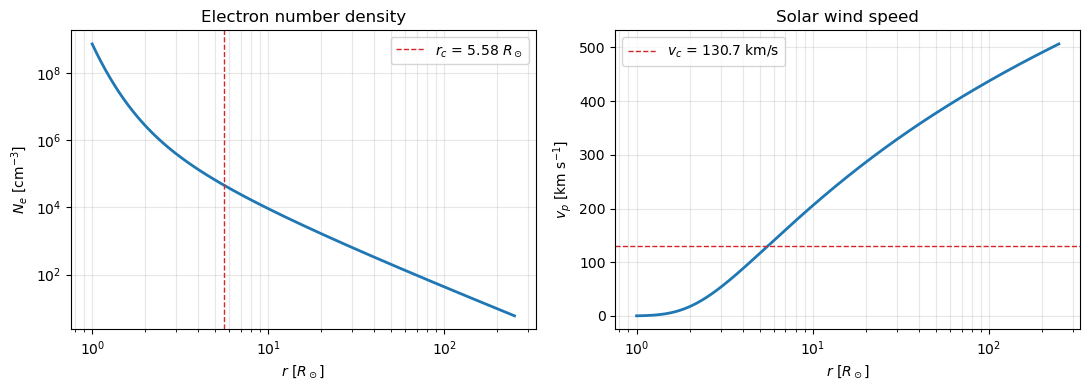

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.loglog(model.r_grid, model.Ne_grid, lw=2)
ax1.set_xlabel(r'$r\ [R_\odot]$')
ax1.set_ylabel(r'$N_e\ [\mathrm{cm}^{-3}]$')
ax1.set_title('Electron number density')
ax1.grid(True, which='both', alpha=0.3)
ax1.axvline(model.r_c/R_SUN, color='C3', ls='--', lw=1, label=rf'$r_c$ = {model.r_c/R_SUN:.2f} $R_\odot$')
ax1.legend()

ax2.semilogx(model.r_grid, model.vp_grid/1e5, lw=2)
ax2.set_xlabel(r'$r\ [R_\odot]$')
ax2.set_ylabel(r'$v_p\ [\mathrm{km\ s}^{-1}]$')
ax2.set_title('Solar wind speed')
ax2.grid(True, which='both', alpha=0.3)
ax2.axhline(model.v_c/1e5, color='C3', ls='--', lw=1, label=f'$v_c$ = {model.v_c/1e5:.1f} km/s')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Sanity checks

Now the important part. A common mistake is to declare a code "validated" because
the printed numbers look like the ones in the paper. That only tells you the two
agree — it does not tell you the code is *correct*. The checks below each compute
a quantity that should hold by physical reasoning, and verify that it does.

### Check 1 — Parker equation residual

If our solver is correct, plugging $v(r)$ back into Parker's equation should
give zero (to machine precision) at every grid point. This is a direct test of
the solver.

In [6]:
r_prime = model.r_grid * R_SUN / model.r_c
v_prime = model.vp_grid / model.v_c
residual = v_prime**2 - np.log(v_prime**2) - (4*np.log(r_prime) + 4/r_prime - 3)

print(f'Parker equation residual:')
print(f'  max |residual| = {np.max(np.abs(residual)):.2e}')
print(f'  mean |residual| = {np.mean(np.abs(residual)):.2e}')
print('Expectation: ~1e-12 or smaller (limited by the Brent tolerance).')

Parker equation residual:
  max |residual| = 9.06e-11
  mean |residual| = 5.05e-13
Expectation: ~1e-12 or smaller (limited by the Brent tolerance).


### Check 2 — Continuity

Steady-state spherical flow conserves the particle flux: $r^2 N_e v_p$ should
equal $C_e$ at every radius. We defined $N_e$ from this relation, so the test
is partly tautological, but it still confirms there are no bugs in how we
combine the solver output with the continuity equation.

In [7]:
flux = (model.r_grid * R_SUN)**2 * model.Ne_grid * model.vp_grid
rel_spread = (flux.max() - flux.min()) / flux.mean()

print(f'C_e on the grid: min = {flux.min():.4e}, max = {flux.max():.4e}')
print(f'C_e input:                  {model.C_e:.4e}')
print(f'Relative spread: {rel_spread:.2e}   (should be ~1e-12)')

C_e on the grid: min = 9.1270e+34, max = 9.1270e+34
C_e input:                  9.1270e+34
Relative spread: 4.04e-16   (should be ~1e-12)


### Check 3 — The near-Sun analytical limit

For $r \ll r_c$ the wind is slow ($v \ll v_c$), so $v'^2$ is negligible compared
to $\ln v'^2$ in Parker's equation. Carrying that approximation through gives the
exponential profile of Eq. 11:

$$N_e(r) \;\approx\; N_{e,\odot}\, \exp\!\left(\frac{2 r_c}{R_\odot}\left[\frac{R_\odot}{r} - 1\right]\right).$$

This is an *independent* prediction — we never used it to build the model. If
our numerical solution does not reduce to this in the inner corona, something is wrong.

In [8]:
r_test = np.array([1.0, 1.2, 1.5, 2.0, 3.0])
Ne_sun = model.density(1.0)
Ne_numerical = model.density(r_test)
Ne_analytic  = Ne_sun * np.exp((2*model.r_c/R_SUN) * (1.0/r_test - 1.0))

print(' r [R_sun]   N_e numerical   N_e analytic (Eq.11)   ratio')
for r, num, ana in zip(r_test, Ne_numerical, Ne_analytic):
    print(f'  {r:5.2f}     {num:.3e}      {ana:.3e}          {num/ana:.4f}')
print()
print('Expectation: ratio -> 1 as r -> R_sun;')
print('             modest deviations at r ~ r_c (5.6 R_sun) where v is no longer negligible.')

 r [R_sun]   N_e numerical   N_e analytic (Eq.11)   ratio
   1.00     7.304e+08      7.304e+08          1.0000
   1.20     1.136e+08      1.136e+08          1.0000
   1.50     1.765e+07      1.766e+07          0.9993
   2.00     2.722e+06      2.746e+06          0.9913
   3.00     3.929e+05      4.270e+05          0.9202

Expectation: ratio -> 1 as r -> R_sun;
             modest deviations at r ~ r_c (5.6 R_sun) where v is no longer negligible.


## 8. Cross-check against the published Table 8

*Now* it is meaningful to compare with the paper. The checks above have already
established that our solver is internally consistent and matches the analytical
limits of the equations. So if our numbers also match Mann et al.'s published
Table 8, that is independent evidence we are computing the same model, not just
the same numbers.

(If we had skipped the sanity checks above and gone straight here, a coincidental
match could hide a bug — e.g. the wrong Parker branch could still happen to produce
plausible-looking numbers at a few radii.)

In [9]:
# Selected values from Mann+2023 Table 8
table8 = np.array([
    # r [R_sun], N_e [cm^-3], v_p [km/s]
    [1.0,   7.17e8, 0.261],
    [2.0,   2.69e6, 17.4 ],
    [5.0,   6.42e4, 116.0],
    [10.0,  9.10e3, 205.0],
    [30.0,  6.32e2, 329.0],
    [100.0, 4.28e1, 437.0],
    [215.0, 8.16,   496.0],
])

r_t8  = table8[:, 0]
Ne_t8 = table8[:, 1]
vp_t8 = table8[:, 2]

Ne_model = model.density(r_t8)
vp_model = np.interp(np.log(r_t8), np.log(model.r_grid), model.vp_grid) / 1e5

print(' r [R_sun]   N_e (us)     N_e (Table 8)   Δ%      v_p (us)   v_p (T8)   Δ%')
for r, ne_us, ne_t8, vp_us, vp_t8_i in zip(r_t8, Ne_model, Ne_t8, vp_model, vp_t8):
    dNe = 100 * (ne_us - ne_t8) / ne_t8
    dvp = 100 * (vp_us - vp_t8_i) / max(vp_t8_i, 1e-3)
    print(f'  {r:6.1f}    {ne_us:9.3e}   {ne_t8:9.3e}     {dNe:+5.2f}    {vp_us:7.2f}    {vp_t8_i:6.1f}    {dvp:+5.2f}')

 r [R_sun]   N_e (us)     N_e (Table 8)   Δ%      v_p (us)   v_p (T8)   Δ%
     1.0    7.304e+08   7.170e+08     +1.87       0.26       0.3    -1.08
     2.0    2.722e+06   2.690e+06     +1.20      17.32      17.4    -0.47
     5.0    6.485e+04   6.420e+04     +1.02     116.31     116.0    +0.27
    10.0    9.183e+03   9.100e+03     +0.91     205.36     205.0    +0.17
    30.0    6.380e+02   6.320e+02     +0.94     328.44     329.0    -0.17
   100.0    4.315e+01   4.280e+01     +0.81     437.06     437.0    +0.01
   215.0    8.232e+00   8.160e+00     +0.88     495.58     496.0    -0.08


Differences of ~1–2 % are expected: they come from us using slightly different
values of $R_\odot$, $M_\odot$ and $G$ than the paper. The shape of the profile is correct.

## 9. Application — radio burst trajectories

Type II and type III bursts radiate at the local plasma frequency
$f_p \;[\text{MHz}] \;\approx\; 8.98 \times 10^{-3}\, \sqrt{N_e\,[\text{cm}^{-3}]}$
(fundamental), or at $2 f_p$ (second harmonic). Tracking the emission down in
frequency over time and inverting through the density model gives you the
radial trajectory of the exciter.

Example: a moderately fast type III drifting from 80 to 30 MHz in 6 seconds
(typical LOFAR LBA frequency range).

In [10]:
def burst_trajectory(freq_MHz, time, harmonic=False, model=None):
    """Map (frequency, time) burst points to (heliocentric distance, time)."""
    if model is None:
        model = MannModel2023()
    f = np.asarray(freq_MHz, dtype=float)
    t = np.asarray(time)
    r = model.radius_from_frequency(f, harmonic=harmonic)
    return r, t, model.density(r)


freqs = np.array([80.0, 60.0, 45.0, 35.0, 30.0])     # MHz
times = np.array([ 0.0,  1.5,  3.0,  4.5,  6.0])     # s
r, t, N_e = burst_trajectory(freqs, times, harmonic=False, model=model)

print(' f [MHz]   t [s]   r [R_sun]   N_e [cm^-3]')
for fi, ti, ri, ni in zip(freqs, t, r, N_e):
    print(f'  {fi:5.1f}   {ti:5.2f}    {ri:6.3f}    {ni:9.3e}')

slope_Rsun_per_s = np.polyfit(t, r, 1)[0]
v_kms = slope_Rsun_per_s * R_SUN / 1e5
print(f'\nMean radial speed of the exciter: {v_kms:.0f} km/s  ({v_kms/3e5:.2f} c)')

 f [MHz]   t [s]   r [R_sun]   N_e [cm^-3]
   80.0    0.00     1.248    7.936e+07
   60.0    1.50     1.334    4.464e+07
   45.0    3.00     1.432    2.511e+07
   35.0    4.50     1.531    1.519e+07
   30.0    6.00     1.598    1.116e+07

Mean radial speed of the exciter: 41620 km/s  (0.14 c)


And the same data, but assuming **harmonic** emission ($f = 2 f_p$). For each
frequency this puts the exciter further from the Sun, because the corresponding
$N_e$ is four times smaller.

In [11]:
r_h, _, N_e_h = burst_trajectory(freqs, times, harmonic=True, model=model)

print(' f [MHz]   r_fund [R_sun]   r_harm [R_sun]   Δr [R_sun]')
for fi, rf, rh in zip(freqs, r, r_h):
    print(f'  {fi:5.1f}    {rf:7.3f}         {rh:7.3f}        {rh-rf:+.3f}')

 f [MHz]   r_fund [R_sun]   r_harm [R_sun]   Δr [R_sun]
   80.0      1.248           1.477        +0.229
   60.0      1.334           1.598        +0.264
   45.0      1.432           1.741        +0.309
   35.0      1.531           1.888        +0.358
   30.0      1.598           1.991        +0.393


## 10. Things to try yourself

- **Min/max envelopes.** Re-instantiate the model with the bounding $(T, C_e)$
  pairs from Table 5 of the paper — point B = (1.21 MK, $6.925\times 10^{34}$ s$^{-1}$)
  for the lower-density bound, point D = (1.14 MK, $11.32\times 10^{34}$ s$^{-1}$) for the
  upper-density bound — and rerun `burst_trajectory`. The spread in $r(t)$ is the
  systematic uncertainty on the inferred kinematics.

- **Compare to a simpler model.** Plot $N_e(r)$ alongside the Leblanc, Dulk & Bougeret
  (1998) formula $N_e(r) = 3.3\!\times\!10^5/R^2 + 4.1\!\times\!10^6/R^4 + 8.0\!\times\!10^7/R^6$ cm$^{-3}$
  (with $R = r/R_\odot$). Where do they agree, where do they diverge, and why?

- **Real data.** Pull a type III event from LOFAR or *Solar Orbiter*/RPW, fit a
  ridge in the dynamic spectrum to get $(f, t)$, feed it through `burst_trajectory`,
  and recover the electron-beam speed.